In [25]:
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [26]:
print("Loading datasets...")
# Without feature Selection
data = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_03\cicids2017_merged.csv')
X = data.drop("Encoded_Label", axis=1)
y = data["Encoded_Label"]
print("Full Dataset shape:", data.shape)

# Top 35 Features Selected
data_top_sec = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_04\cicids2017_selected_top_features.csv')
X_top_sec = data_top_sec.drop("Encoded_Label", axis=1)
y_top_sec = data_top_sec["Encoded_Label"]
print("Top Features Dataset shape:", data_top_sec.shape)

Loading datasets...
Full Dataset shape: (2520751, 81)
Top Features Dataset shape: (2520751, 36)


In [27]:
print("\nLoading scalers and transforming data...")
scaler = joblib.load(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\scaler.pkl")
scaler_rnn_top_sec = joblib.load(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn_scaler_top_sec.pkl")
scaler_bilstm = joblib.load(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\scaler_bilstm.pkl")
scaler_bilstm_top_sec = joblib.load(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\scaler_bilstm_top_features.pkl")

# Transform datasets to float32 arrays
X_rnn_scaled = scaler.transform(X.select_dtypes(include=[np.number]).astype(np.float32))
X_rnn_scaled_top_sec = scaler_rnn_top_sec.transform(X_top_sec.select_dtypes(include=[np.number]).astype(np.float32))

X_bilstm_scaled = scaler_bilstm.transform(X.select_dtypes(include=[np.number]).astype(np.float32))
X_bilstm_scaled_top_sec = scaler_bilstm_top_sec.transform(X_top_sec.select_dtypes(include=[np.number]).astype(np.float32))


Loading scalers and transforming data...


In [28]:
print("\nSplitting data...")
_, X_temp, _, y_temp = train_test_split(X_rnn_scaled, y, test_size=0.3, stratify=y, random_state=42)
_, X_rnn_test, _, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

_, X_rnn_top_temp, _, _ = train_test_split(X_rnn_scaled_top_sec, y, test_size=0.3, stratify=y, random_state=42)
_, X_rnn_top_test, _, _ = train_test_split(X_rnn_top_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

_, X_bilstm_temp, _, _ = train_test_split(X_bilstm_scaled, y, test_size=0.3, stratify=y, random_state=42)
_, X_bilstm_test, _, _ = train_test_split(X_bilstm_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

_, X_bilstm_top_temp, _, _ = train_test_split(X_bilstm_scaled_top_sec, y, test_size=0.3, stratify=y, random_state=42)
_, X_bilstm_top_test, _, _ = train_test_split(X_bilstm_top_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


Splitting data...


In [29]:
# 4. Reshape Data for 3D Input (Samples, Timesteps, Features)
X_rnn_test_reshaped = np.array(X_rnn_test).reshape(X_rnn_test.shape[0], X_rnn_test.shape[1], 1)
X_rnn_top_test_reshaped = np.array(X_rnn_top_test).reshape(X_rnn_top_test.shape[0], X_rnn_top_test.shape[1], 1)

X_bilstm_test_reshaped = np.array(X_bilstm_test).reshape(X_bilstm_test.shape[0], X_bilstm_test.shape[1], 1)
X_bilstm_top_test_reshaped = np.array(X_bilstm_top_test).reshape(X_bilstm_top_test.shape[0], X_bilstm_top_test.shape[1], 1)

In [30]:
# 5. Load Models
print("\nLoading models...")
rnn_model = tf.keras.models.load_model(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn\rnn_model.h5")
rnn_model_top_sec = tf.keras.models.load_model(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn\rnn_top_sec_model.h5")

bilstm_model = tf.keras.models.load_model(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\bilstm_model.h5")
bilstm_model_top_sec = tf.keras.models.load_model(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\bilstm_model_top_features.h5")


Loading models...


In [31]:
def evaluate_and_extract(model, X_test, y_test, name, batch_size=1024):
    print(f"\n===== {name} RESULTS =====")
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Accuracy: {acc:.4f}, Loss: {loss:.4f}")
    
    y_pred = model.predict(X_test, batch_size=batch_size, verbose=0)
    y_pred_classes = y_pred.argmax(axis=1)
    
    print(classification_report(y_test, y_pred_classes, digits=4))
    
    macro_f1 = f1_score(y_test, y_pred_classes, average='macro')
    weighted_f1 = f1_score(y_test, y_pred_classes, average='weighted')
    
    class_f1_scores = f1_score(y_test, y_pred_classes, average=None)
    class_1_f1 = class_f1_scores[1] if len(class_f1_scores) > 1 else 0.0
    
    metrics = {
        "Model Configuration": name,
        "Accuracy": round(acc, 4),
        "Loss": round(loss, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "Class 1 F1 (Minority)": round(class_1_f1, 4)
    }
    return metrics, y_pred_classes

In [32]:
results = []

# RNN Full
rnn_metrics, rnn_preds = evaluate_and_extract(rnn_model, X_rnn_test_reshaped, y_test, "RNN (Full Features)")
results.append(rnn_metrics)

# RNN Top 35
rnn_top_metrics, _ = evaluate_and_extract(rnn_model_top_sec, X_rnn_top_test_reshaped, y_test, "RNN (Top 35 Features)")
results.append(rnn_top_metrics)

# BiLSTM Full
bilstm_metrics, bilstm_preds = evaluate_and_extract(bilstm_model, X_bilstm_test_reshaped, y_test, "BiLSTM (Full Features)")
results.append(bilstm_metrics)

# BiLSTM Top 35
bilstm_top_metrics, _ = evaluate_and_extract(bilstm_model_top_sec, X_bilstm_top_test_reshaped, y_test, "BiLSTM (Top 35 Features)")
results.append(bilstm_top_metrics)


===== RNN (Full Features) RESULTS =====
Accuracy: 0.9522, Loss: 0.1629
              precision    recall  f1-score   support

           0     0.9989    0.9441    0.9707    314259
           1     0.0948    0.7089    0.1672       292
           2     0.4508    0.9774    0.6170      1373
           3     0.9150    0.9987    0.9550     19202
           4     0.8655    0.9895    0.9233     29062
           5     0.7116    0.9971    0.8305     13604
           6     0.1130    0.9408    0.2018       321

    accuracy                         0.9522    378113
   macro avg     0.5928    0.9366    0.6665    378113
weighted avg     0.9706    0.9522    0.9587    378113


===== RNN (Top 35 Features) RESULTS =====
Accuracy: 0.9506, Loss: 0.1438
              precision    recall  f1-score   support

           0     0.9987    0.9422    0.9696    314259
           1     0.0002    0.0034    0.0003       292
           2     0.7295    0.9701    0.8328      1373
           3     0.9085    0.9991    0.9


Generating evaluation plots and tables...


,Accuracy,Loss,Macro F1,Weighted F1,Class 1 F1 (Minority)
Model Configuration,,,,,
RNN (Full Features),0.9522,0.1629,0.6665,0.9587,0.1672
RNN (Top 35 Features),0.9506,0.1438,0.6865,0.9599,0.0003
BiLSTM (Full Features),0.9489,0.1432,0.6869,0.9542,0.1819
BiLSTM (Top 35 Features),0.9358,0.1765,0.6488,0.9456,0.0000


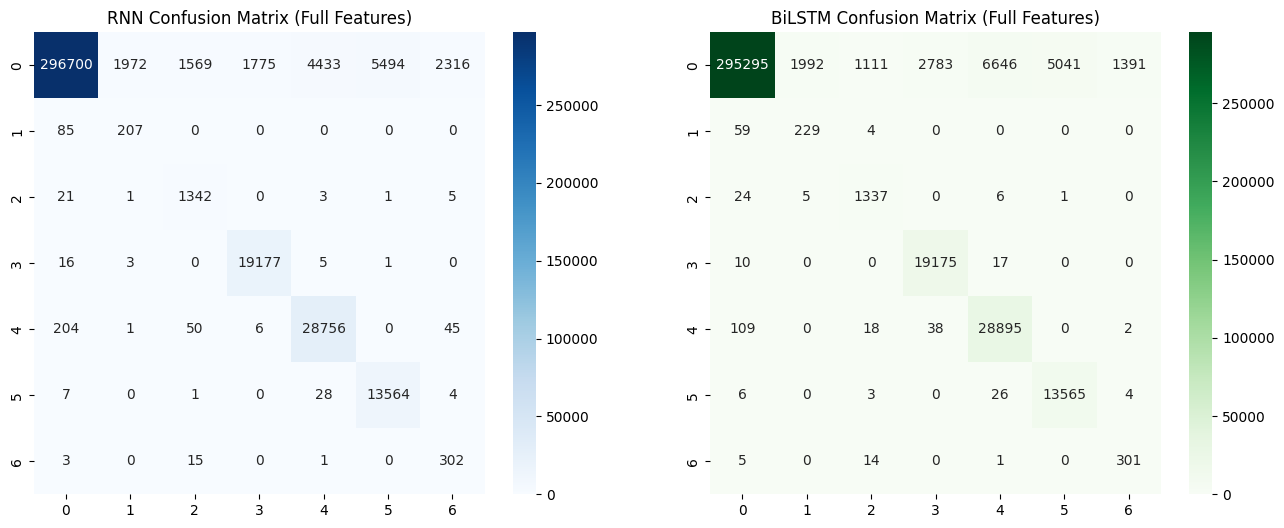

In [33]:
print("\nGenerating evaluation plots and tables...")

# 7.1 Metrics DataFrame
comparison_df = pd.DataFrame(results).set_index("Model Configuration")
display(comparison_df) # Renders cleanly in Jupyter

# 7.2 Confusion Matrices
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, rnn_preds), annot=True, cmap='Blues', fmt='d')
plt.title("RNN Confusion Matrix (Full Features)")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, bilstm_preds), annot=True, cmap='Greens', fmt='d')
plt.title("BiLSTM Confusion Matrix (Full Features)")
plt.show()

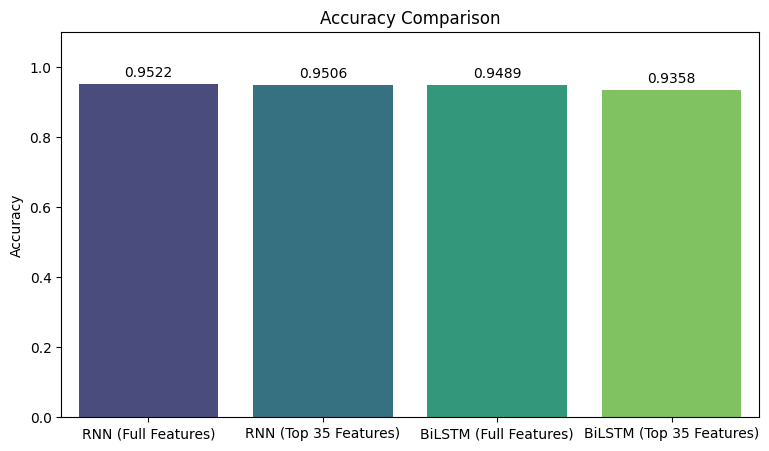

In [34]:
models_labels = comparison_df.index.tolist()

plt.figure(figsize=(9,5))
sns.barplot(x=models_labels, y=comparison_df["Accuracy"], hue=models_labels, palette="viridis", legend=False)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
for i, v in enumerate(comparison_df["Accuracy"]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
plt.show()

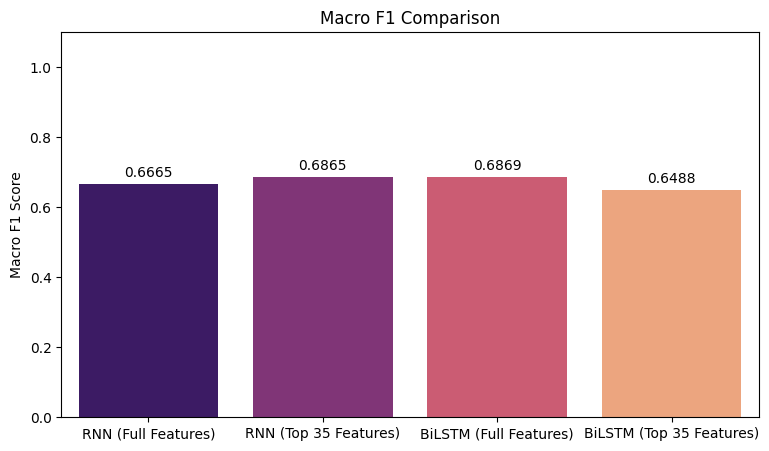

In [35]:
plt.figure(figsize=(9,5))
sns.barplot(x=models_labels, y=comparison_df["Macro F1"], hue=models_labels, palette="magma", legend=False)
plt.title("Macro F1 Comparison")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1.1)
for i, v in enumerate(comparison_df["Macro F1"]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
plt.show()